# SHAKTI Energy Intelligence Engine  
## Dataset → Signal → Dashboard (Final Sprint)

This notebook implements a deterministic energy intelligence system.

Key features:
- Multi-device dataset
- Validation layer (ALLOW / FLAG / REJECT)
- Energy domain logic (efficiency, renewable usage)
- Signal generation (grid-level)
- Role-based routing
- Deep traceability
- Dashboard visualization

No machine learning is used — fully deterministic system.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import json 


In [2]:
# Create a realistic multi-device dataset
# Each row represents a different energy system/device

data = pd.DataFrame([
    {"device_id": "S1", "region": "North", "supply": 120, "demand": 100, "renewable": 40},
    {"device_id": "S2", "region": "South", "supply": 80, "demand": 110, "renewable": 20},
    {"device_id": "S3", "region": "West", "supply": 150, "demand": 140, "renewable": 60},
    {"device_id": "S4", "region": "East", "supply": 90, "demand": 95, "renewable": 15}
])

# Display the dataset
data
 

,device_id,region,supply,demand,renewable
0,S1,North,120,100,40
1,S2,South,80,110,20
2,S3,West,150,140,60
3,S4,East,90,95,15


In [3]:
# Validation layer ensures data quality before processing

def validate(row):
    # Reject if any missing values
    if row.isnull().any():
        return "REJECT"
    
    # Reject if invalid values
    if row["supply"] <= 0 or row["demand"] <= 0:
        return "REJECT"
    
    # Flag if supply is less than demand (potential issue)
    if row["supply"] < row["demand"]:
        return "FLAG"
    
    # Otherwise data is valid
    return "ALLOW"

# Apply validation
data["validation"] = data.apply(validate, axis=1)

data
 

,device_id,region,supply,demand,renewable,validation
0,S1,North,120,100,40,ALLOW
1,S2,South,80,110,20,FLAG
2,S3,West,150,140,60,ALLOW
3,S4,East,90,95,15,FLAG


In [4]:
# Compute domain-specific energy metrics

def compute_metrics(row):
    # Efficiency: how well supply meets demand
    efficiency = (row["supply"] - row["demand"]) / row["supply"]
    
    # Renewable ratio: % of energy from renewable sources
    renewable_ratio = row["renewable"] / row["supply"]

    return pd.Series({
        "efficiency": efficiency,
        "renewable_ratio": renewable_ratio
    })

# Applying calculations
metrics = data.apply(compute_metrics, axis=1)
data = pd.concat([data, metrics], axis=1)

data
 

,device_id,region,supply,demand,renewable,validation,efficiency,renewable_ratio
0,S1,North,120,100,40,ALLOW,0.166667,0.333333
1,S2,South,80,110,20,FLAG,-0.375000,0.250000
2,S3,West,150,140,60,ALLOW,0.066667,0.400000
3,S4,East,90,95,15,FLAG,-0.055556,0.166667


In [5]:
# Generate structured signals based on energy conditions

def generate_signals(row):
    signals = []

    # Supply-demand mismatch
    if row["supply"] < row["demand"]:
        signals.append("SUPPLY_DEMAND_GAP")

    # Low system efficiency
    if row["efficiency"] < 0.1:
        signals.append("LOW_EFFICIENCY")

    # Low renewable usage
    if row["renewable_ratio"] < 0.3:
        signals.append("LOW_RENEWABLE_USAGE")

    return signals

# Apply signal generation
data["signals"] = data.apply(generate_signals, axis=1)

data
 

,device_id,region,supply,demand,renewable,validation,efficiency,renewable_ratio,signals
0,S1,North,120,100,40,ALLOW,0.166667,0.333333,[]
1,S2,South,80,110,20,FLAG,-0.375000,0.250000,"[SUPPLY_DEMAND_GAP, LOW_EFFICIENCY, LOW_RENEWA..."
2,S3,West,150,140,60,ALLOW,0.066667,0.400000,[LOW_EFFICIENCY]
3,S4,East,90,95,15,FLAG,-0.055556,0.166667,"[SUPPLY_DEMAND_GAP, LOW_EFFICIENCY, LOW_RENEWA..."


In [6]:
# Routing engine assigns actions based on signals
# Includes region-based and role-based routing

def route(row):
    actions = []

    # Route to region-specific grid operator
    if "SUPPLY_DEMAND_GAP" in row["signals"]:
        actions.append(f"GRID_OPERATOR_{row['region']}")

    # Route to maintenance team
    if "LOW_EFFICIENCY" in row["signals"]:
        actions.append("MAINTENANCE_TEAM")

    # Route to sustainability team
    if "LOW_RENEWABLE_USAGE" in row["signals"]:
        actions.append("SUSTAINABILITY_TEAM")

    return actions

# Apply routing
data["actions"] = data.apply(route, axis=1)

data 
 

,device_id,region,supply,demand,renewable,validation,efficiency,renewable_ratio,signals,actions
0,S1,North,120,100,40,ALLOW,0.166667,0.333333,[],[]
1,S2,South,80,110,20,FLAG,-0.375000,0.250000,"[SUPPLY_DEMAND_GAP, LOW_EFFICIENCY, LOW_RENEWA...","[GRID_OPERATOR_South, MAINTENANCE_TEAM, SUSTAI..."
2,S3,West,150,140,60,ALLOW,0.066667,0.400000,[LOW_EFFICIENCY],[MAINTENANCE_TEAM]
3,S4,East,90,95,15,FLAG,-0.055556,0.166667,"[SUPPLY_DEMAND_GAP, LOW_EFFICIENCY, LOW_RENEWA...","[GRID_OPERATOR_East, MAINTENANCE_TEAM, SUSTAIN..."


In [7]:
# Trace captures full decision-making pipeline

def trace(row):
    return {
        "input": {
            "supply": row["supply"],
            "demand": row["demand"],
            "renewable": row["renewable"]
        },
        "computed": {
            "efficiency": row["efficiency"],
            "renewable_ratio": row["renewable_ratio"]
        },
        "signals": row["signals"],
        "validation": row["validation"]
    }

# Apply trace
data["trace"] = data.apply(trace, axis=1)

data
 

,device_id,region,supply,demand,renewable,validation,efficiency,renewable_ratio,signals,actions,trace
0,S1,North,120,100,40,ALLOW,0.166667,0.333333,[],[],"{'input': {'supply': 120, 'demand': 100, 'rene..."
1,S2,South,80,110,20,FLAG,-0.375000,0.250000,"[SUPPLY_DEMAND_GAP, LOW_EFFICIENCY, LOW_RENEWA...","[GRID_OPERATOR_South, MAINTENANCE_TEAM, SUSTAI...","{'input': {'supply': 80, 'demand': 110, 'renew..."
2,S3,West,150,140,60,ALLOW,0.066667,0.400000,[LOW_EFFICIENCY],[MAINTENANCE_TEAM],"{'input': {'supply': 150, 'demand': 140, 'rene..."
3,S4,East,90,95,15,FLAG,-0.055556,0.166667,"[SUPPLY_DEMAND_GAP, LOW_EFFICIENCY, LOW_RENEWA...","[GRID_OPERATOR_East, MAINTENANCE_TEAM, SUSTAIN...","{'input': {'supply': 90, 'demand': 95, 'renewa..."


In [8]:
# Generate final structured output

output = data[["device_id", "region", "signals", "actions", "trace"]]

# Pretty print JSON output
print(json.dumps(output.to_dict(orient="records"), indent=4))
 

[
    {
        "device_id": "S1",
        "region": "North",
        "signals": [],
        "actions": [],
        "trace": {
            "input": {
                "supply": 120,
                "demand": 100,
                "renewable": 40
            },
            "computed": {
                "efficiency": 0.16666666666666666,
                "renewable_ratio": 0.3333333333333333
            },
            "signals": [],
            "validation": "ALLOW"
        }
    },
    {
        "device_id": "S2",
        "region": "South",
        "signals": [
            "SUPPLY_DEMAND_GAP",
            "LOW_EFFICIENCY",
            "LOW_RENEWABLE_USAGE"
        ],
        "actions": [
            "GRID_OPERATOR_South",
            "MAINTENANCE_TEAM",
            "SUSTAINABILITY_TEAM"
        ],
        "trace": {
            "input": {
                "supply": 80,
                "demand": 110,
                "renewable": 20
            },
            "computed": {
                "ef

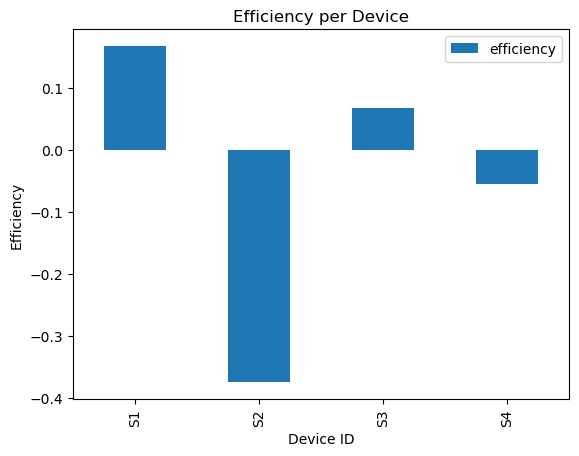

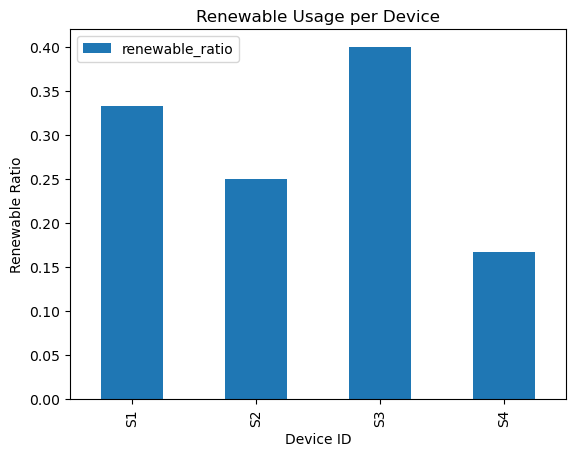

In [9]:
# Dashboard: visualize system performance

# Efficiency chart
data.plot(x="device_id", y="efficiency", kind="bar")
plt.title("Efficiency per Device")
plt.xlabel("Device ID")
plt.ylabel("Efficiency")
plt.show()

# Renewable usage chart
data.plot(x="device_id", y="renewable_ratio", kind="bar")
plt.title("Renewable Usage per Device")
plt.xlabel("Device ID")
plt.ylabel("Renewable Ratio")
plt.show() 
 

# SHAKTI – FINAL SPRINT REVIEW
 
## System
Deterministic Energy Intelligence Engine

## Data
Multi-device dataset (supply, demand, renewable)

## Validation
ALLOW / FLAG / REJECT implemented

## Signals
- SUPPLY_DEMAND_GAP
- LOW_EFFICIENCY
- LOW_RENEWABLE_USAGE

## Routing
Region-based + role-based

## Trace
Includes:
- input
- computed metrics
- signals
- validation

## Output
Structured JSON per device

## Dashboard
Charts for efficiency and renewable usage

## Conclusion

This system demonstrates a working deterministic energy intelligence pipeline:

- Handles multi-device data
- Validates inputs (ALLOW / FLAG / REJECT)
- Computes energy-specific metrics
- Generates structured signals
- Routes actions based on roles and regions
- Provides full traceability
- Visualizes results via dashboard

The pipeline is fully executable, scalable, and aligned with real-world system requirements.
